<a href="https://colab.research.google.com/github/Sanika-tech123/Deep-Learning-Lab/blob/main/DL_7_Classifying_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


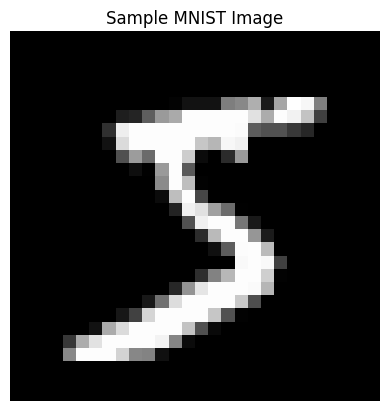

Label: 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.9382 - loss: 0.2084 - val_accuracy: 0.9712 - val_loss: 0.0972
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9790 - loss: 0.0682 - val_accuracy: 0.9802 - val_loss: 0.0628
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9859 - loss: 0.0467 - val_accuracy: 0.9794 - val_loss: 0.0679
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.9898 - loss: 0.0331 - val_accuracy: 0.9827 - val_loss: 0.0588
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9916 - loss: 0.0260 - val_accuracy: 0.9835 - val_loss: 0.0550
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9821 - loss: 0.0560

Test Accuracy: 0.9821000099182129
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

Predicted Digit: 7


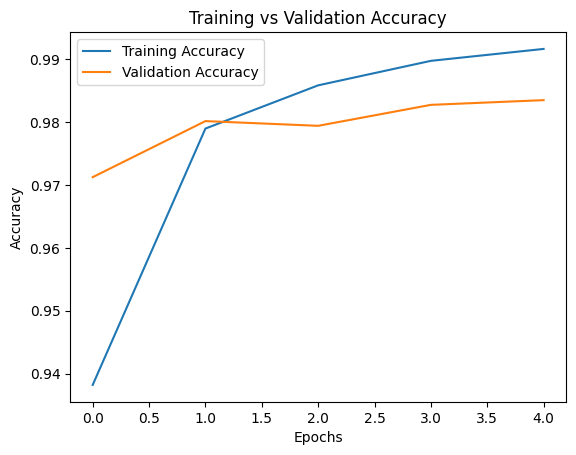

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load MNIST Dataset
# ---------------------------------------------------

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset Loaded Successfully")

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

# ---------------------------------------------------
# Display Sample Image
# ---------------------------------------------------

plt.imshow(X_train[0], cmap='gray')

plt.title("Sample MNIST Image")

plt.axis('off')

plt.show()

print("Label:", y_train[0])

# ---------------------------------------------------
# Normalize Data
# ---------------------------------------------------

X_train = X_train / 255.0
X_test = X_test / 255.0

# ---------------------------------------------------
# Reshape Data for CNN
# ---------------------------------------------------

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# ---------------------------------------------------
# Build CNN Model
# ---------------------------------------------------

model = Sequential()

# Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(28,28,1)))

# Pooling Layer
model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# ---------------------------------------------------
# Compile Model
# ---------------------------------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------
# Train Model
# ---------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

# ---------------------------------------------------
# Evaluate Model
# ---------------------------------------------------

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# ---------------------------------------------------
# Make Prediction
# ---------------------------------------------------

prediction = model.predict(X_test[:1])

print("\nPredicted Digit:",
      prediction.argmax())

# ---------------------------------------------------
# Plot Accuracy Graph
# ---------------------------------------------------

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()